# NeRF

**To run NeRF, first run the COLMAP pipeline to get the poses and focal**

## Load Data

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Pose normalisation: scene_center=[ 0.00011177 -0.03892376  0.07644694], scale=1.0774
  Camera distance range after scaling: 3.504 – 4.545
  Suggested near=1.75, far=6.82
(111, 800, 600, 3) (111, 4, 4) 952.3795521469099 800 600
Using device: cuda
Pose example:
 [[ 0.9979943   0.01114484  0.06231525  0.03053334]
 [ 0.00828516 -0.9989088   0.04596204  1.5314177 ]
 [ 0.06275949 -0.04535356 -0.99699765 -3.1836445 ]
 [ 0.          0.          0.          1.        ]]


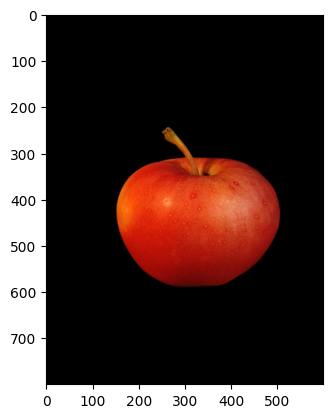

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../utils")
from colmap import load_nerf_data_from_colmap

train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/1",
    images_dir = "../data/images",
    image_size = (800, 600), # optional resize
    normalize_poses = True,  # centres scene and scales cameras to r≈4 (near=2/far=6)
)

H, W = train_images.shape[1:3]
print(train_images.shape, train_poses.shape, focal, H, W)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Pose example:\n", train_poses[0])
plt.imshow(test_images[0])
plt.show()
focal = np.array(focal)
testimg = torch.from_numpy(test_images[0]).float().to(device)
testpose = torch.from_numpy(test_poses[0]).float().to(device)

## Train Model

Using device: cuda


Training NeRF:   0%|          | 0/90000 [00:08<?, ?iter/s, loss=0.252370, psnr=6.64]

Iteration: 0, Loss: 0.252370, Time: 0.00 secs per iter


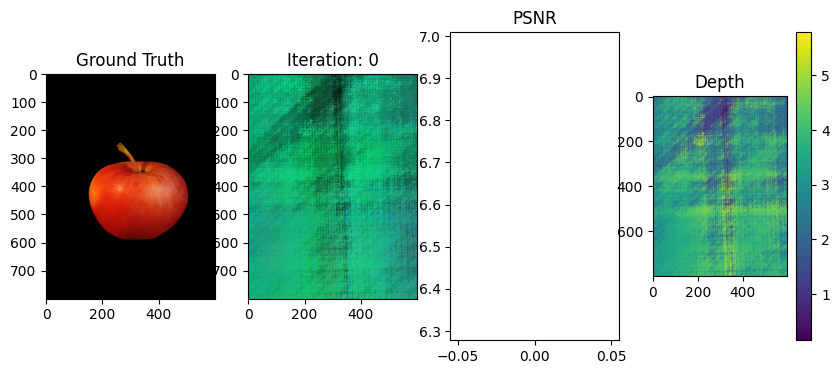

Training NeRF:  11%|█         | 10000/90000 [52:48<3:29:42,  6.36iter/s, loss=0.000436, psnr=36.56]

Iteration: 10000, Loss: 0.000436, Time: 0.32 secs per iter


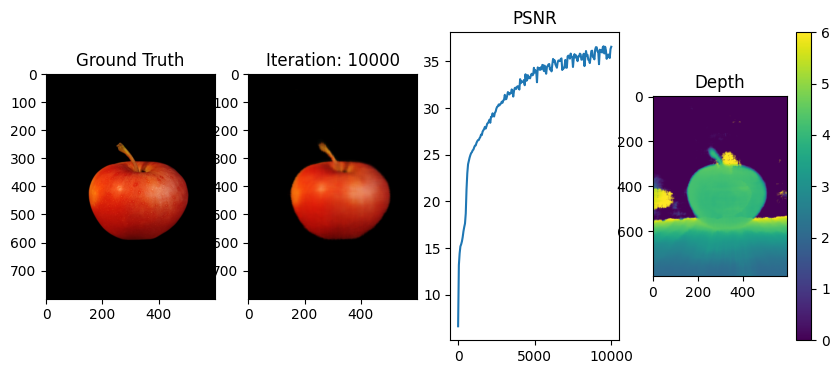

Training NeRF:  22%|██▏       | 20000/90000 [1:45:10<3:03:49,  6.35iter/s, loss=0.000262, psnr=36.00] 

Iteration: 20000, Loss: 0.000262, Time: 0.31 secs per iter


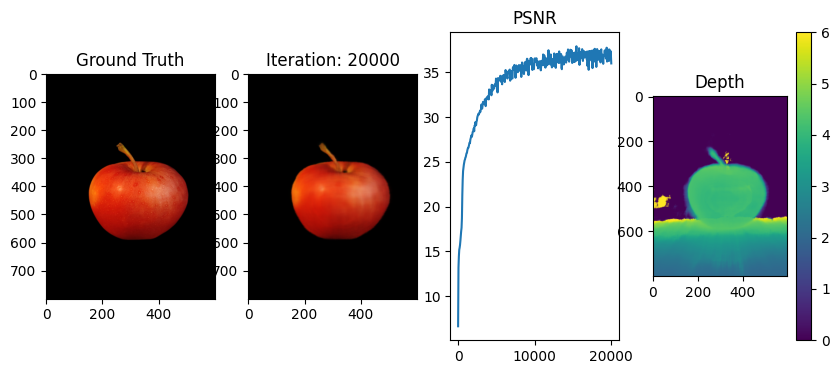

Training NeRF:  33%|███▎      | 30000/90000 [2:40:02<2:36:50,  6.38iter/s, loss=0.000181, psnr=37.02] 

Iteration: 30000, Loss: 0.000181, Time: 0.33 secs per iter


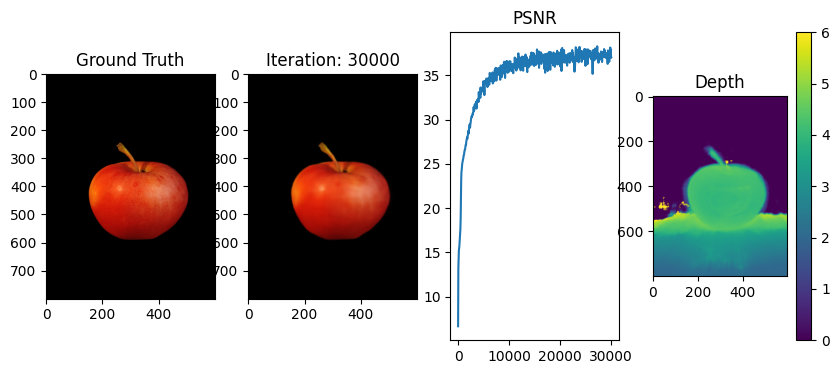

Training NeRF:  44%|████▍     | 40000/90000 [3:32:41<2:11:13,  6.35iter/s, loss=0.000189, psnr=37.66] 

Iteration: 40000, Loss: 0.000189, Time: 0.32 secs per iter


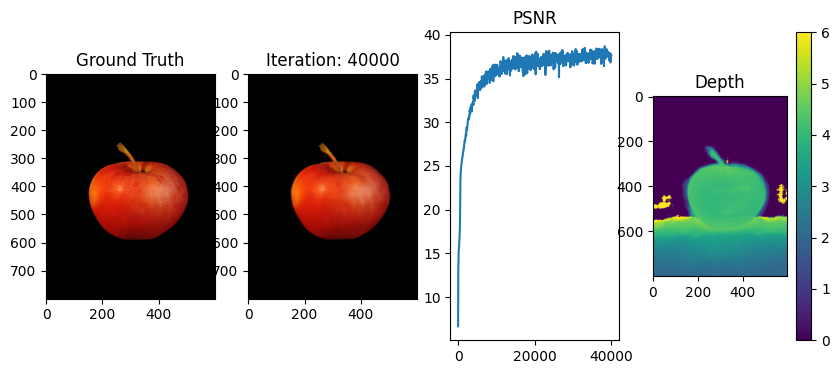

Training NeRF:  56%|█████▌    | 50000/90000 [4:25:57<1:54:58,  5.80iter/s, loss=0.000143, psnr=38.26] 

Iteration: 50000, Loss: 0.000143, Time: 0.32 secs per iter


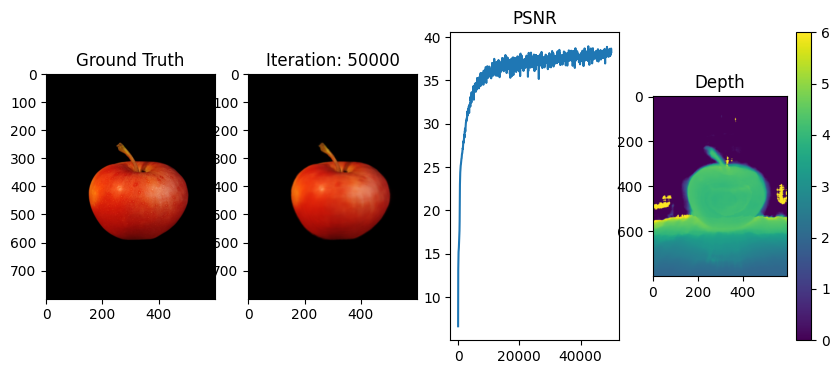

Training NeRF:  67%|██████▋   | 60000/90000 [5:24:02<1:51:21,  4.49iter/s, loss=0.000166, psnr=38.91] 

Iteration: 60000, Loss: 0.000166, Time: 0.35 secs per iter


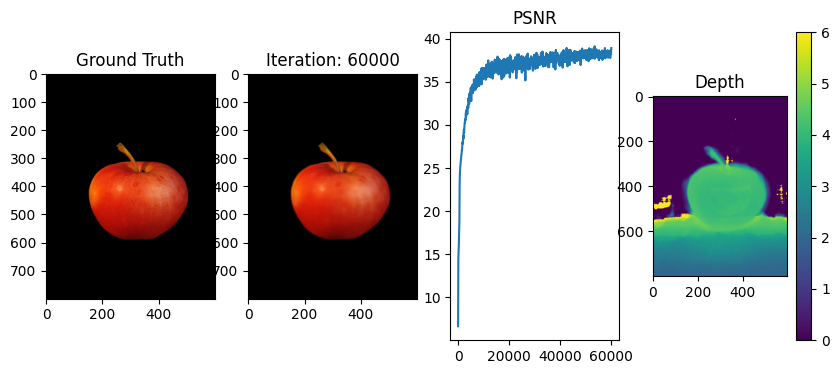

Training NeRF:  78%|███████▊  | 70000/90000 [6:14:17<41:55,  7.95iter/s, loss=0.000115, psnr=38.83]   

Iteration: 70000, Loss: 0.000115, Time: 0.30 secs per iter


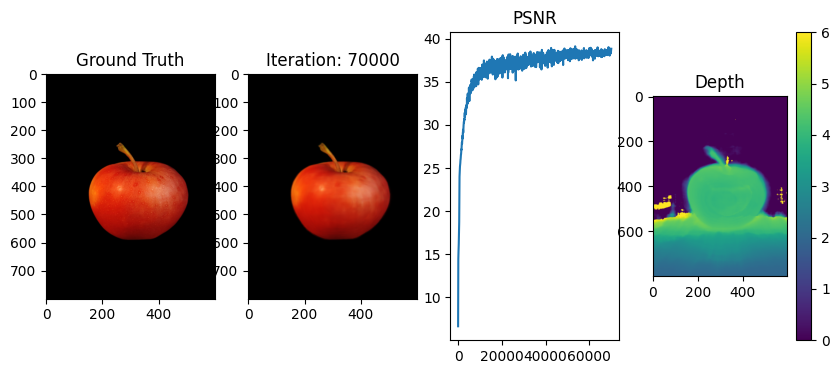

Training NeRF:  89%|████████▉ | 80000/90000 [7:17:24<37:09,  4.49iter/s, loss=0.000152, psnr=38.63]   

Iteration: 80000, Loss: 0.000152, Time: 0.38 secs per iter


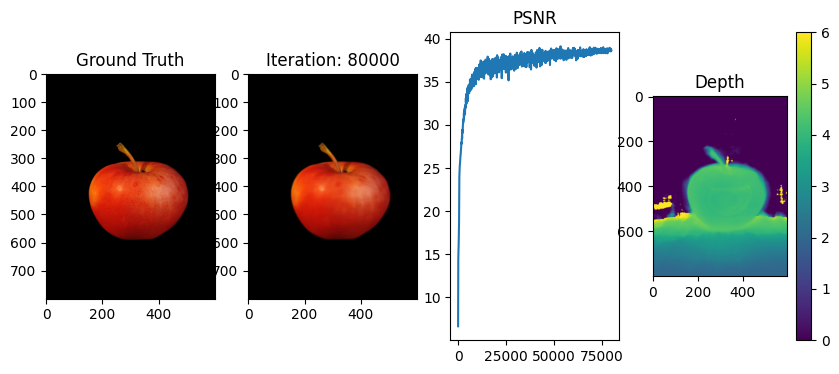

Training NeRF: 100%|██████████| 90000/90000 [8:10:38<00:00,  3.06iter/s, loss=0.000119, psnr=38.56]   


In [2]:
import sys
sys.path.append("../utils")
from nerf import train

n_iter = 90000
n_samples = 64
i_plot = 10000  # Interval for plotting
i_val = 50     # Interval for calculating val_loss

model = train(train_images, train_poses, H, W, focal, testpose, testimg, n_iter, n_samples, i_plot, i_val, device)

## Save the model

In [3]:
from pathlib import Path

save_dir = Path("../results/nerf")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "nerf_model.pt"
torch.save(model.state_dict(), model_path)

print(f"Saved trained model to: {model_path.resolve()}")

Saved trained model to: C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf\nerf_model.pt


## Load the model

In [4]:
import torch
from pathlib import Path
import sys
sys.path.append("../utils")
from nerf import NeRF

save_dir = Path("../results/nerf")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "nerf_model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = NeRF().to(device)

# Load saved weights into the existing model instance
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print(f"Loaded model from: {model_path.resolve()}")

Loaded model from: C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf\nerf_model.pt


## Render Video

In [5]:
import sys
sys.path.append("../utils")
import numpy as np
from colmap import load_nerf_data_from_colmap

train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/1",
    images_dir = "../data/images",
    image_size = (800, 600), # optional resize
    normalize_poses = True,  # centres scene and scales cameras to r≈4 (near=2/far=6)
)

H, W = train_images.shape[1:3]
focal = np.array(focal)

Pose normalisation: scene_center=[ 0.00011177 -0.03892376  0.07644694], scale=1.0774
  Camera distance range after scaling: 3.504 – 4.545
  Suggested near=1.75, far=6.82


In [6]:
from tqdm import tqdm
from nerf import get_rays, render_rays

frames = []
frames_depth = []
for pose in tqdm(train_poses):
    c2w = torch.from_numpy(pose).float()
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device=device)
    rgb = rgb.reshape(H, W, 3)
    frames.append((255 * np.clip(rgb.cpu().detach().numpy(), 0, 1)).astype(np.uint8))
    frames_depth.append((255 * np.clip(depth.cpu().detach().numpy(), 0, 1)).astype(np.uint8))

100%|██████████| 111/111 [25:09<00:00, 13.60s/it]


In [7]:
import imageio
imageio.mimwrite('../results/nerf/video.mp4', frames, fps=30, quality=7)
frames_depth_reshaped = [f.reshape(H, W).astype(np.float32) for f in frames_depth]

cmap = plt.get_cmap("viridis")
frames_depth_colored = []

# Use global normalization (less frame-to-frame contrast pumping)
global_min = min(d.min() for d in frames_depth_reshaped)
global_max = max(d.max() for d in frames_depth_reshaped)
eps = 1e-8

# Contrast factor < 1 makes differences more subtle
contrast = 0.65

for d in frames_depth_reshaped:
    d_norm = (d - global_min) / (global_max - global_min + eps)
    d_soft = 0.5 + (d_norm - 0.5) * contrast
    d_soft = np.clip(d_soft, 0.0, 1.0)
    d_rgb = (cmap(d_soft)[..., :3] * 255).astype(np.uint8)
    frames_depth_colored.append(d_rgb)

imageio.mimwrite('../results/nerf/video_depth.mp4', frames_depth_colored, fps=30, quality=7)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 800) to (608, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 800) to (608, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [8]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('../results/nerf/video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [9]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('../results/nerf/video_depth.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

## Marching Cubes

In [14]:
import torch
import numpy as np
import mcubes
import sys
sys.path.append("../utils")
from scipy import ndimage

@torch.no_grad()
def query_density_and_color(model, pts, device, chunk=1024*16):
    """Query sigma + averaged RGB (over 6 axis-aligned view dirs)."""
    view_axes = [
        [ 0,  0, -1], [ 0,  0,  1],
        [ 1,  0,  0], [-1,  0,  0],
        [ 0,  1,  0], [ 0, -1,  0],
    ]
    sigmas, rgbs_accum = [], None
    for vi, axis in enumerate(view_axes):
        v_dir = torch.tensor([axis], dtype=torch.float32).expand(pts.shape[0], -1).to(device)
        rgbs_v = []
        for i in range(0, pts.shape[0], chunk):
            out = model(torch.cat([pts[i:i+chunk], v_dir[i:i+chunk]], dim=-1))
            if vi == 0:
                sigmas.append(out[:, 0].cpu())
            rgbs_v.append(out[:, 1:].cpu())
        rgb_cat = torch.cat(rgbs_v)
        rgbs_accum = rgb_cat if rgbs_accum is None else rgbs_accum + rgb_cat
    return torch.cat(sigmas), rgbs_accum / len(view_axes)


@torch.no_grad()
def extract_geometry_hires(model, device, coarse_res=128, fine_res=512,
                           bound=1.55, density_threshold=None, sigma_smooth=1.0,
                           pad=0.15):
    # ---- COARSE PASS: find tight bounding box + sigma statistics ----
    lin_c = torch.linspace(-bound, bound, coarse_res)
    xs, ys, zs = torch.meshgrid(lin_c, lin_c, lin_c, indexing='ij')
    pts_c = torch.stack([xs, ys, zs], dim=-1).reshape(-1, 3).to(device)
    sig_c, _ = query_density_and_color(model, pts_c, device)
    sig_c = sig_c.reshape(coarse_res, coarse_res, coarse_res).numpy()

    # Print sigma distribution to help choose a good threshold
    pcts = [50, 75, 90, 95, 99, 99.5, 99.9]
    vals = np.percentile(sig_c, pcts)
    print("Sigma distribution (coarse grid):")
    print(f"  min={sig_c.min():.4f}  max={sig_c.max():.4f}  mean={sig_c.mean():.4f}")
    for p, v in zip(pcts, vals):
        print(f"  p{p}={v:.4f}")

    # Auto-select threshold: 99th percentile of the coarse sigma, but at least 0.01
    if density_threshold is None:
        density_threshold = float(np.percentile(sig_c, 99))
        density_threshold = max(density_threshold, 0.01)
        print(f"\nAuto-selected density_threshold={density_threshold:.4f}")
    else:
        frac = np.mean(sig_c > density_threshold)
        print(f"\nUsing density_threshold={density_threshold:.4f}  (fraction occupied coarse: {frac:.4f})")
        if frac == 0:
            fallback = float(np.percentile(sig_c, 99))
            fallback = max(fallback, 0.01)
            print(f"  → 0 occupied voxels at that threshold! Falling back to p99={fallback:.4f}")
            density_threshold = fallback

    # Find occupied voxels → tight world-space box
    mask_c = sig_c > density_threshold * 0.3
    if mask_c.any():
        occ = np.argwhere(mask_c)
        ijk_min = occ.min(axis=0)
        ijk_max = occ.max(axis=0)
        step = 2 * bound / (coarse_res - 1)
        lo = -bound + ijk_min * step - pad
        hi = -bound + ijk_max * step + pad
    else:
        lo = np.full(3, -bound)
        hi = np.full(3,  bound)
    print(f"Tight box: [{lo[0]:.3f},{lo[1]:.3f},{lo[2]:.3f}] → [{hi[0]:.3f},{hi[1]:.3f},{hi[2]:.3f}]")

    # ---- FINE PASS: dense query only inside tight box ----
    slab_count = 8
    lin_x = torch.linspace(float(lo[0]), float(hi[0]), fine_res)
    lin_y = torch.linspace(float(lo[1]), float(hi[1]), fine_res)
    lin_z = torch.linspace(float(lo[2]), float(hi[2]), fine_res)

    sigma_vol = np.zeros((fine_res, fine_res, fine_res), dtype=np.float32)
    rgb_vol   = np.zeros((fine_res, fine_res, fine_res, 3), dtype=np.float32)

    slab_size = fine_res // slab_count
    for s in range(slab_count):
        i0 = s * slab_size
        i1 = min(i0 + slab_size, fine_res)
        xs_s, ys_s, zs_s = torch.meshgrid(lin_x[i0:i1], lin_y, lin_z, indexing='ij')
        pts_s = torch.stack([xs_s, ys_s, zs_s], dim=-1).reshape(-1, 3).to(device)
        sig_s, rgb_s = query_density_and_color(model, pts_s, device)
        nx = i1 - i0
        sigma_vol[i0:i1] = sig_s.reshape(nx, fine_res, fine_res).numpy()
        rgb_vol[i0:i1]   = np.clip(rgb_s.reshape(nx, fine_res, fine_res, 3).numpy(), 0, 1)
        print(f"  Slab {s+1}/{slab_count} done")

    print(f"\nFine grid sigma: min={sigma_vol.min():.4f}  max={sigma_vol.max():.4f}")
    print(f"Fraction above threshold: {np.mean(sigma_vol > density_threshold):.4f}")

    # ---- Gaussian smooth to reduce staircase artifacts ----
    if sigma_smooth > 0:
        sigma_vol = ndimage.gaussian_filter(sigma_vol, sigma=sigma_smooth)

    # ---- Largest connected component ----
    binary = sigma_vol > density_threshold
    labeled, num_features = ndimage.label(binary)
    if num_features > 1:
        sizes = ndimage.sum(binary, labeled, range(1, num_features + 1))
        largest = np.argmax(sizes) + 1
        sigma_vol[labeled != largest] = 0.0
        print(f"Kept component {largest}/{num_features} ({int(sizes[np.argmax(sizes)])} voxels)")

    # ---- Marching cubes ----
    verts, faces = mcubes.marching_cubes(sigma_vol, density_threshold)

    # Grid indices → world coordinates
    verts_world = np.column_stack([
        np.interp(verts[:, 0], [0, fine_res-1], [lo[0], hi[0]]),
        np.interp(verts[:, 1], [0, fine_res-1], [lo[1], hi[1]]),
        np.interp(verts[:, 2], [0, fine_res-1], [lo[2], hi[2]]),
    ])

    # ---- Trilinear vertex colors ----
    vi = np.clip(verts.copy(), 0, fine_res - 1.001)
    i0 = np.floor(vi).astype(int)
    frac = vi - i0
    i1 = np.minimum(i0 + 1, fine_res - 1)
    w000 = (1-frac[:,0])*(1-frac[:,1])*(1-frac[:,2])
    w001 = (1-frac[:,0])*(1-frac[:,1])*(  frac[:,2])
    w010 = (1-frac[:,0])*(  frac[:,1])*(1-frac[:,2])
    w011 = (1-frac[:,0])*(  frac[:,1])*(  frac[:,2])
    w100 = (  frac[:,0])*(1-frac[:,1])*(1-frac[:,2])
    w101 = (  frac[:,0])*(1-frac[:,1])*(  frac[:,2])
    w110 = (  frac[:,0])*(  frac[:,1])*(1-frac[:,2])
    w111 = (  frac[:,0])*(  frac[:,1])*(  frac[:,2])
    vert_colors = (
        w000[:,None]*rgb_vol[i0[:,0],i0[:,1],i0[:,2]] +
        w001[:,None]*rgb_vol[i0[:,0],i0[:,1],i1[:,2]] +
        w010[:,None]*rgb_vol[i0[:,0],i1[:,1],i0[:,2]] +
        w011[:,None]*rgb_vol[i0[:,0],i1[:,1],i1[:,2]] +
        w100[:,None]*rgb_vol[i1[:,0],i0[:,1],i0[:,2]] +
        w101[:,None]*rgb_vol[i1[:,0],i0[:,1],i1[:,2]] +
        w110[:,None]*rgb_vol[i1[:,0],i1[:,1],i0[:,2]] +
        w111[:,None]*rgb_vol[i1[:,0],i1[:,1],i1[:,2]]
    )
    vert_colors = np.clip(vert_colors, 0, 1)

    return verts_world, faces, vert_colors, density_threshold


verts, faces, colors, used_threshold = extract_geometry_hires(
    model, device,
    coarse_res=128, fine_res=256,
    bound=2.0, density_threshold=None,  # auto-detect threshold from sigma distribution
    sigma_smooth=0.5, pad=0.15,
)
print(f"\nThreshold used: {used_threshold:.4f}")
print(f"Vertices: {verts.shape}, Faces: {faces.shape}")

Sigma distribution (coarse grid):
  min=0.0000  max=44.8976  mean=0.1385
  p50=0.0000
  p75=0.0000
  p90=0.0000
  p95=0.0000
  p99=5.0555
  p99.5=6.4011
  p99.9=8.2418

Auto-selected density_threshold=5.0555
Tight box: [-1.898,-1.079,0.370] → [1.331,2.150,2.150]
  Slab 1/8 done
  Slab 2/8 done
  Slab 3/8 done
  Slab 4/8 done
  Slab 5/8 done
  Slab 6/8 done
  Slab 7/8 done
  Slab 8/8 done

Fine grid sigma: min=0.0000  max=48.4669
Fraction above threshold: 0.0446
Kept component 3/111 (688862 voxels)

Threshold used: 5.0555
Vertices: (231002, 3), Faces: (460278, 3)


In [15]:
import open3d as o3d

mesh = o3d.geometry.TriangleMesh()
mesh.vertices  = o3d.utility.Vector3dVector(verts)
mesh.triangles = o3d.utility.Vector3iVector(faces)
mesh.vertex_colors = o3d.utility.Vector3dVector(colors)
mesh.compute_vertex_normals()

# Remove degenerate triangles and unreferenced vertices
mesh.remove_degenerate_triangles()
mesh.remove_unreferenced_vertices()

# Light Laplacian smoothing (preserves detail, removes staircase jaggies)
mesh = mesh.filter_smooth_laplacian(number_of_iterations=5, lambda_filter=0.5)
mesh.compute_vertex_normals()

o3d.io.write_triangle_mesh("../results/nerf/mesh.ply", mesh)
print(f"Saved mesh.ply — {len(mesh.vertices)} verts, {len(mesh.triangles)} faces")
o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

Saved mesh.ply — 231002 verts, 460278 faces


## Converting to point clouds

In [16]:
import numpy as np
import open3d as o3d

mesh = o3d.io.read_triangle_mesh("../results/nerf/mesh.ply")
verts = np.asarray(mesh.vertices)
tris  = np.asarray(mesh.triangles)

# optional per-vertex colors (if present)
has_colors = mesh.has_vertex_colors()
vcols = np.asarray(mesh.vertex_colors) if has_colors else None

# face areas
f0 = verts[tris[:,0]]
f1 = verts[tris[:,1]]
f2 = verts[tris[:,2]]

areas = 0.5 * np.linalg.norm(np.cross(f1 - f0, f2 - f0), axis=1)
probs = areas / areas.sum()

def sample_points_on_mesh(n_points):
    face_idx = np.random.choice(len(tris), size=n_points, p=probs)
    r1 = np.sqrt(np.random.rand(n_points))
    r2 = np.random.rand(n_points)
    a = 1 - r1
    b = r1 * (1 - r2)
    c = r1 * r2
    p = (a[:,None]*verts[tris[face_idx,0]] +
         b[:,None]*verts[tris[face_idx,1]] +
         c[:,None]*verts[tris[face_idx,2]])
    if has_colors:
        color = (a[:,None]*vcols[tris[face_idx,0]] +
                 b[:,None]*vcols[tris[face_idx,1]] +
                 c[:,None]*vcols[tris[face_idx,2]])
    else:
        color = None
    return p, color

pts, cols = sample_points_on_mesh(300_000)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)
if cols is not None:
    pcd.colors = o3d.utility.Vector3dVector(cols)
o3d.io.write_point_cloud("../results/nerf/pointcloud_area_uniform.ply", pcd)
o3d.visualization.draw_geometries([pcd])